# Neural Networks using Tensorflow

In [20]:
from pickletools import optimize

import cv2 as cv
import numpy as np
import os
import zipfile
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

## Extracting pixels from images

### Extracting dataset from zip

In [21]:
path = '../zz9_Material/Datasets/homer_bart_1.zip'
zip_object= zipfile.ZipFile(file= path, mode = 'r')
zip_object.extractall('../Course_Materials/Datasets/')
zip_object.close()

In [22]:
directory = '../Course_Materials/Datasets/homer_bart_1'
files = [os.path.join(directory, f) for f in sorted(os.listdir(directory))]
# runs thro the files and reads the images, resizes them, appends them to a list only if they are jpg files
#print(files)

In [23]:
h, w = 128, 128
images = []
classes = []

for img_path in files:
    image = cv.imread(img_path)

    if image is None:
        continue

    image_resized = cv.resize(image, (w, h))
    image_gray = cv.cvtColor(image_resized, cv.COLOR_BGR2GRAY)
    #images.append(image_gray)

    image_flat = image_gray.ravel()
    images.append(image_flat)

    img_name = os.path.basename(img_path)
    if img_name.startswith('b'):
        class_name = 0
    else:
        class_name = 1
    classes.append(class_name)
    #print(classes)

print(images[0])
print(f"size after ravel: {image.shape}")
#if images:
#        plt.imshow(images[0], cmap='gray')
#        plt.title(f"Greyscale Shape: {images[0].shape}")
#         plt.show()
#        print(class_name)


[255 255 255 ... 255 255 255]
size after ravel: (742, 509, 3)


### why greyscale image

when resize image --> channels/3

greyscale --> 128*128 = 1638 neurons // big but better than 49152

In [24]:
x = np.array(images)
y = np.array(classes)

In [25]:
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

x shape: (269, 16384)
y shape: (269,)


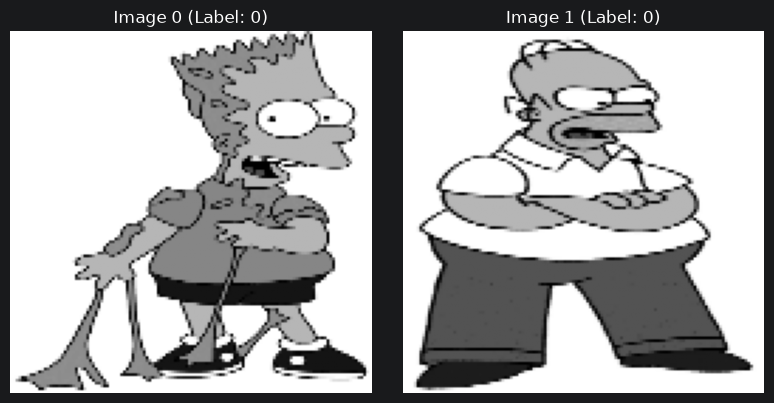

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(x[0].reshape(h, w), cmap='gray')
axes[0].set_title(f"Image 0 (Label: {y[0]})")
axes[0].axis('off')

axes[1].imshow(x[200].reshape(h, w), cmap='gray')
axes[1].set_title(f"Image 1 (Label: {y[1]})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

(array([0, 1]), array([160, 109]))


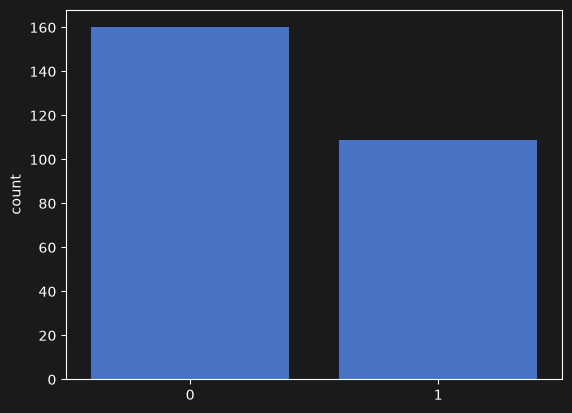

In [27]:
sns.countplot(x=y)
print(np.unique(y, return_counts=True))

## Normalising the data

In [28]:
from sklearn.preprocessing import MinMaxScaler

In [29]:
x[0].max(), x[0].min()

(np.uint8(255), np.uint8(0))

In [30]:
sc = MinMaxScaler()
x = sc.fit_transform(x)
x[0].max(), x[0].min()


(np.float64(1.0000000000000002), np.float64(0.0))

## train test


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x,y , test_size = 0.2, random_state = 42)
print(x_train.shape)
print(x_test.shape, "\n")
print(y_train.shape)
print(y_test.shape)

(215, 16384)
(54, 16384) 

(215,)
(54,)


## Building and training neural netowrk

In [33]:
# how many neurons in hidden layer
(16384 + 2) /2 # --> 8193

8193.0

In [34]:
network1 = tf.keras.models.Sequential()
# input layer --> 16384 px
network1.add(tf.keras.layers.Dense(input_shape=(16384,), units=8193))
network1.add(tf.keras.layers.Dense(units=8193, activation='relu'))
network1.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid')) # binary classification



/home/suupatruupa/Documents/hmph/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
network1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
## compile
# https://keras.io/api/optimizers/
# https://keras.io/api/losses/
network1.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [37]:
history = network1.fit(x_train, y_train, epochs = 40)

Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4977 - loss: 547.7338
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5070 - loss: 192.2514
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4884 - loss: 315.5990
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4605 - loss: 256.1954
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4977 - loss: 47.7583
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4930 - loss: 28.3845
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5535 - loss: 36.8103
Epoch 8/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4930 - loss: 60.5258
Epoch 9/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5256 - loss: 23.5688
Epoch 10/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5116 - loss: 47.5296
Epoch 11/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5767 - loss: 12.0428
Epoch 12/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4698 - loss: 21.3230
Epoch 13

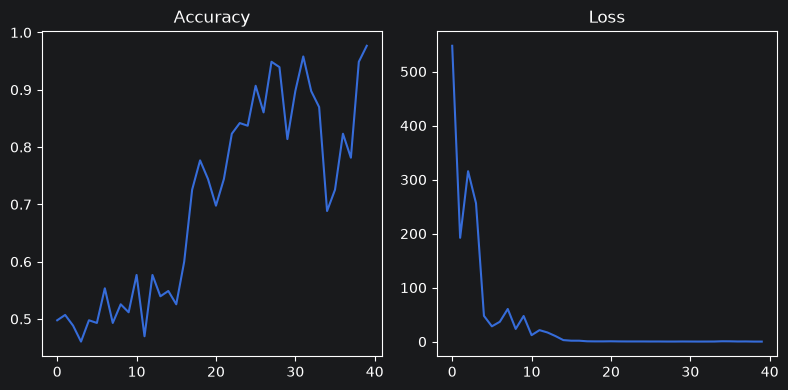

In [47]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], color='blue', label='Accuracy')
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)

axes[1].plot(history.history['loss'], color='red', label='Loss')
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()

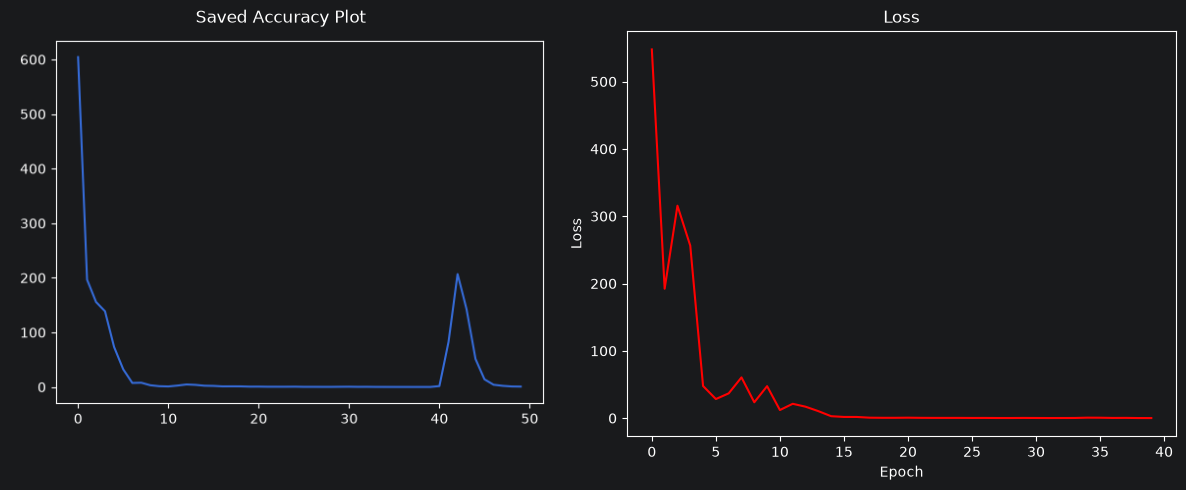

In [55]:
img = cv.imread('output.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Saved Accuracy Plot")
axes[0].axis('off')

axes[1].plot(history.history['loss'], color='red')
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

## Evaluation


In [63]:
pred = network1.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step


In [66]:
# 0 --> false (bart)
# 1 --> true (homer)
pred = (pred > 0.5)
pred

array([[ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True]])

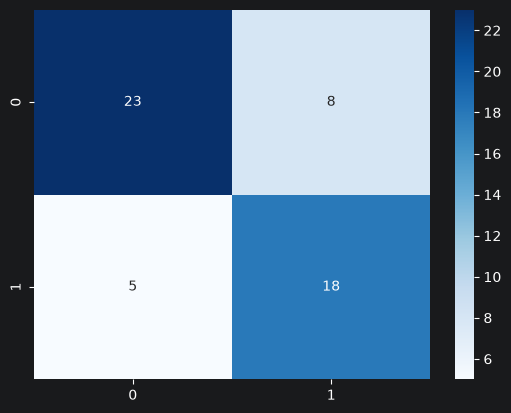

In [74]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
accuracy_score(y_test, pred) # 75% accurate yay

cm = confusion_matrix(y_test, pred)
#disp = ConfusionMatrixDisplay(cm)
#isp.plot()
sns.heatmap(cm, annot=True, cmap='Blues');
plt.show()

In [77]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.82      0.74      0.78        31
           1       0.69      0.78      0.73        23

    accuracy                           0.76        54
   macro avg       0.76      0.76      0.76        54
weighted avg       0.77      0.76      0.76        54



## save and load network

In [81]:
modeljs = network1.to_json()
with open('MYFIRSTNETWORKEVER.json', 'w') as json_file:
    json_file.write(modeljs)

In [80]:
from keras.models import save_model
network1saved = save_model(network1, 'MYFIRSTNETWORKEVER_weight.hdf5')

## loading saved files

In [82]:
with open('MYFIRSTNETWORKEVER.json') as json_file:
    json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential_1", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 16384], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer_1", "optional": false}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense_3", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 8193, "activation": "linear", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null, "input_axes": null, "output_axes": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registere

In [83]:
network1_loaded = tf.keras.models.model_from_json(json_saved_model)
network1_loaded.load_weights('MYFIRSTNETWORKEVER_weight.hdf5')
network1_loaded.compile(loss= 'binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
network1_loaded.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

## classify an image using extracted model

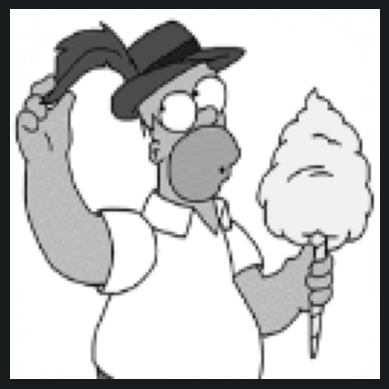

In [100]:
test_img = x_test[33].reshape(w,h)
img_unscaled = sc.inverse_transform(x_test[33].reshape(1, -1))
test_img = img_unscaled.reshape(h, w).astype('uint8')
plt.imshow(test_img, cmap='gray')
plt.axis('off')
plt.show()

In [99]:
predn = network1_loaded.predict(x_test[32:33])
prob = predn[0][0]
predC = "Homer" if prob >= 0.5 else "Bart"

print(f"Confidence Score: {probability:.4f}") # 66%
print(f"Predicted Character: {predicted_class}") # homer ITS TRUE YAYAYYA

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Confidence Score: 0.6623
Predicted Character: Homer
